In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Установить стиль как в FREYJA анализе
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 10)

In [3]:
# Ground Truth
ground_truth_percentages = [
    [0.901, 0, 0.128, 98.132, 0, 0, 0.450, 0, 0, 0, 0.386],
    [3.225, 0, 0.444, 91.657, 0, 0, 2.780, 0, 0, 0, 1.890],
    [8.211, 0.182, 0.669, 86.678, 0.121, 0, 3.102, 0, 0, 0, 1.034],
    [5.664, 0.129, 0.284, 89.730, 0.078, 0.360, 2.224, 0, 0, 0, 1.526],
    [5.454, 0.122, 0.531, 90.357, 0.265, 0.102, 2.226, 0, 0, 0, 0.939],
    [9.690, 0.169, 0.120, 84.001, 0.338, 0.072, 3.528, 0, 0.024, 0, 2.054],
    [12.816, 0.394, 0.037, 78.701, 0.319, 0.037, 6.173, 0, 0.075, 0, 1.444],
    [13.509, 0.305, 0.051, 78.666, 0.368, 0.089, 6.042, 0, 0.051, 0, 0.915],
    [20.555, 0.462, 0.060, 68.716, 0.207, 0.146, 7.891, 0, 0.036, 0, 1.924],
    [28.074, 0.752, 0.014, 60.096, 0.184, 0.170, 8.875, 0, 0.156, 0, 1.675],
    [39.221, 0.848, 0.066, 46.540, 0.613, 0.379, 10.767, 0.011, 0.100, 0, 1.450],
    [43.730, 0.879, 0.017, 42.697, 0.469, 0.896, 10.081, 0.025, 0.093, 0.008, 1.101],
    [52.638, 0.966, 0.041, 30.400, 0.575, 1.274, 12.986, 0.041, 0.233, 0.006, 0.836],
    [59.192, 0.986, 0.060, 23.009, 0.551, 1.942, 13.444, 0.090, 0.125, 0.005, 0.595],
    [63.386, 0.962, 0.076, 16.452, 0.511, 3.007, 15.055, 0.056, 0.132, 0.004, 0.354],
    [68.156, 0.941, 0.126, 11.588, 0.443, 4.464, 13.626, 0.097, 0.203, 0.003, 0.349],
    [71.272, 0.984, 0.205, 8.356, 0.430, 5.516, 12.728, 0.171, 0.191, 0.011, 0.132],
    [71.693, 0.935, 0.491, 6.260, 0.365, 6.729, 12.998, 0.193, 0.238, 0, 0.092],
    [72.674, 0.830, 1.133, 4.876, 0.385, 7.625, 11.917, 0.192, 0.328, 0, 0.037],
    [73.363, 0.914, 1.560, 3.653, 0.350, 9.314, 10.406, 0.117, 0.280, 0.003, 0.031],
    [73.655, 0.907, 2.258, 2.952, 0.285, 10.116, 9.386, 0.086, 0.325, 0.011, 0.014],
    [72.514, 0.733, 3.193, 2.273, 0.176, 11.428, 9.279, 0.038, 0.343, 0.014, 0.004],
    [70.802, 0.851, 5.351, 1.491, 0.157, 12.237, 8.661, 0.018, 0.422, 0.006, 0],
    [66.962, 0.536, 10.030, 1.309, 0.114, 13.353, 7.226, 0.017, 0.430, 0.008, 0.008],
    [58.024, 0.331, 19.942, 0.741, 0.199, 13.704, 6.691, 0.011, 0.331, 0, 0.022],
    [49.989, 0.220, 32.039, 0.490, 0.110, 12.037, 4.652, 0, 0.460, 0, 0],
    [39.350, 0.120, 46.363, 0.290, 0.040, 10.328, 3.085, 0.010, 0.410, 0, 0],
    [24.301, 0.050, 64.570, 0.192, 0.033, 8.595, 1.819, 0, 0.419, 0.017, 0],
    [15.025, 0.062, 77.618, 0.062, 0.013, 5.887, 1.099, 0, 0.229, 0, 0],
    [7.749, 0.028, 88.004, 0.028, 0, 3.407, 0.532, 0, 0.247, 0, 0],
    [3.907, 0.014, 93.662, 0.008, 0.002, 2.032, 0.211, 0, 0.160, 0, 0],
    [1.931, 0.014, 96.704, 0.013, 0, 1.166, 0.076, 0, 0.093, 0, 0],
    [1.051, 0.001, 98.147, 0.006, 0, 0.697, 0.043, 0, 0.052, 0, 0],
    [0.480, 0.002, 98.651, 0, 0, 0.490, 0.321, 0, 0.053, 0, 0],
    [0.254, 0.001, 99.457, 0, 0, 0.246, 0.014, 0, 0.025, 0, 0],
    [0.142, 0.001, 99.533, 0.119, 0, 0.162, 0.014, 0.001, 0.023, 0, 0],
    [0.065, 0.001, 99.811, 0.002, 0, 0.110, 0.002, 0.001, 0.004, 0, 0],
    [0.050, 0.001, 99.894, 0.001, 0, 0.042, 0.002, 0, 0.006, 0, 0],
    [0.029, 0, 99.935, 0.001, 0, 0.028, 0.002, 0, 0.002, 0, 0],
    [0.054, 0, 99.780, 0.119, 0, 0.039, 0.005, 0, 0, 0, 0],
    [0.005, 0, 99.984, 0, 0, 0.010, 0, 0, 0, 0, 0],
    [0.008, 0, 99.976, 0, 0, 0.015, 0, 0, 0, 0, 0]
]

In [4]:
lineages = ['Alpha', 'Beta', 'Delta', 'Epsilon', 'Eta', 'Gamma', 'Iota', 'Kappa', 'Lambda', 'Theta', 'Zeta']

In [5]:
# Создать DataFrame для Ground Truth
gt_df = pd.DataFrame(ground_truth_percentages, columns=lineages)
gt_df['Sample'] = [f'S{i+1}' for i in range(42)]

In [6]:
# Загрузить данные Kallisto
kallisto_df = pd.read_csv('/home/nicolaedrabcinski/research/metbio/results/viorel_dataset_KALLISTO_2/plots/results_table.csv')
# kallisto_df = pd.read_csv('/home/nicolaedrabcinski/research/metbio/results/viorel_dataset/plots/results_table.csv')

kallisto_df['Sample'] = 'S' + kallisto_df['sample'].str.replace('sample_', '')
kallisto_df = kallisto_df.drop('sample', axis=1)
kallisto_df

,Alpha,Beta,Delta,Epsilon,Eta,Gamma,Iota,Kappa,Lambda,Zeta,Sample
0,1.382,1.484,3.654,70.113,0.055,2.281,6.644,1.995,6.424,5.904,S1
1,4.809,0.479,2.808,66.736,0.042,1.962,10.200,0.781,4.051,8.083,S2
2,11.627,0.812,2.603,63.485,0.104,1.730,10.254,1.229,3.781,4.323,S3
3,8.408,0.954,2.237,65.562,0.081,2.220,8.817,1.232,4.170,6.264,S4
4,8.268,0.885,2.799,65.827,0.195,1.997,8.951,1.265,4.725,5.036,S5
5,13.277,0.608,1.393,61.824,0.202,1.832,10.501,0.682,3.118,6.517,S6
6,16.680,0.649,1.040,58.336,0.203,1.657,14.327,0.451,2.394,4.223,S7
7,17.500,0.611,1.131,58.171,0.230,1.647,14.527,0.453,2.584,3.087,S8
8,23.873,0.579,0.827,51.937,0.138,1.577,15.378,0.254,1.199,4.193,S9
9,30.200,0.717,0.565,46.295,0.130,1.361,15.804,0.222,1.276,3.379,S10


In [7]:
# Проверка данных
print(f"Ground Truth samples: {len(gt_df)}")
print(f"Kallisto samples: {len(kallisto_df)}")
print(f"Ground Truth columns: {list(gt_df.columns)}")
print(f"Kallisto columns: {list(kallisto_df.columns)}")

Ground Truth samples: 42
Kallisto samples: 42
Ground Truth columns: ['Alpha', 'Beta', 'Delta', 'Epsilon', 'Eta', 'Gamma', 'Iota', 'Kappa', 'Lambda', 'Theta', 'Zeta', 'Sample']
Kallisto columns: ['Alpha', 'Beta', 'Delta', 'Epsilon', 'Eta', 'Gamma', 'Iota', 'Kappa', 'Lambda', 'Zeta', 'Sample']


In [8]:
# Проверка суммы процентов
gt_sums = gt_df[lineages].sum(axis=1)
kallisto_sums = kallisto_df[kallisto_df.columns.difference(['Sample'])].sum(axis=1)
print(f"\nGround Truth сумма: Min={gt_sums.min():.2f}%, Max={gt_sums.max():.2f}%, Mean={gt_sums.mean():.2f}%")
print(f"Kallisto сумма: Min={kallisto_sums.min():.2f}%, Max={kallisto_sums.max():.2f}%, Mean={kallisto_sums.mean():.2f}%")


Ground Truth сумма: Min=99.99%, Max=100.00%, Mean=100.00%
Kallisto сумма: Min=99.93%, Max=99.98%, Mean=99.96%


In [9]:
# Ground Truth в длинный формат (исключаем Theta для соответствия Kallisto)
kallisto_lineages = ['Alpha', 'Beta', 'Delta', 'Epsilon', 'Eta', 'Gamma', 'Iota', 'Kappa', 'Lambda', 'Zeta']
gt_long = gt_df.melt(
    id_vars=['Sample'], 
    value_vars=kallisto_lineages,
    var_name='Lineage', 
    value_name='True_Abundance'
)

In [10]:
# Kallisto в длинный формат
kallisto_long = kallisto_df.melt(
    id_vars=['Sample'], 
    value_vars=kallisto_lineages,
    var_name='Lineage', 
    value_name='Predicted_Abundance'
)

In [11]:
# Объединить данные
comparison_df = pd.merge(gt_long, kallisto_long, on=['Sample', 'Lineage'], how='inner')

print(f"\nОбъединенные данные: {len(comparison_df)} сравнений")
print(f"Уникальные образцы: {comparison_df['Sample'].nunique()}")
print(f"Уникальные линии: {comparison_df['Lineage'].nunique()}")


Объединенные данные: 420 сравнений
Уникальные образцы: 42
Уникальные линии: 10


In [12]:
# Вычисление метрик
comparison_df_filtered = comparison_df.copy()
print(f"\nВсего сравнений: {len(comparison_df_filtered)}")
print(f"\nСравнений после фильтрации: {len(comparison_df_filtered)}")


Всего сравнений: 420

Сравнений после фильтрации: 420


In [13]:
mae = mean_absolute_error(comparison_df_filtered['True_Abundance'], 
                          comparison_df_filtered['Predicted_Abundance'])
rmse = np.sqrt(mean_squared_error(comparison_df_filtered['True_Abundance'], 
                                   comparison_df_filtered['Predicted_Abundance']))
r2 = r2_score(comparison_df_filtered['True_Abundance'], 
              comparison_df_filtered['Predicted_Abundance'])

In [14]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(comparison_df_filtered['True_Abundance'], 
                                       comparison_df_filtered['Predicted_Abundance'])

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(comparison_df_filtered['True_Abundance'], 
                                          comparison_df_filtered['Predicted_Abundance'])

# Вычислить среднюю относительную ошибку (только для ненулевых true values)
comparison_df_filtered['absolute_error'] = np.abs(
    comparison_df_filtered['Predicted_Abundance'] - comparison_df_filtered['True_Abundance']
)

In [15]:
# Относительная ошибка только где True > 0.001
nonzero_true = comparison_df_filtered[comparison_df_filtered['True_Abundance'] > 0.001].copy()
nonzero_true['relative_error'] = (nonzero_true['absolute_error'] / nonzero_true['True_Abundance']) * 100

mean_relative_error = nonzero_true['relative_error'].mean()
median_relative_error = nonzero_true['relative_error'].median()

In [16]:
print(f"Dataset: 42 samples with {len(kallisto_lineages)} lineages")
print(f"Comparison: Ground Truth (%) vs Kallisto Predictions (%)")
print("-" * 70)
print(f"Mean Absolute Error (MAE):              {mae:.4f}%")
print(f"Root Mean Squared Error (RMSE):         {rmse:.4f}%")
print(f"R² Score:                               {r2:.4f}")
print(f"Pearson Correlation (r):                {pearson_r:.4f} (p={pearson_p:.2e})")
print(f"Spearman Correlation (ρ):               {spearman_r:.4f} (p={spearman_p:.2e})")
print("-" * 70)
print(f"Mean Relative Error:                    {mean_relative_error:.2f}%")
print(f"Median Relative Error:                  {median_relative_error:.2f}%")
print(f"Total comparisons:                      {len(comparison_df_filtered)}")
print(f"Comparisons with True > 0.001%:           {len(nonzero_true)}")

Dataset: 42 samples with 10 lineages
Comparison: Ground Truth (%) vs Kallisto Predictions (%)
----------------------------------------------------------------------
Mean Absolute Error (MAE):              4.4766%
Root Mean Squared Error (RMSE):         9.2773%
R² Score:                               0.8528
Pearson Correlation (r):                0.9497 (p=7.04e-213)
Spearman Correlation (ρ):               0.6462 (p=5.30e-51)
----------------------------------------------------------------------
Mean Relative Error:                    6669.92%
Median Relative Error:                  43.60%
Total comparisons:                      420
Comparisons with True > 0.001%:           332


In [17]:
# Метрики по линиям
print(f"{'Lineage':<12} {'n':<6} {'MAE':<10} {'RMSE':<10} {'R²':<10} {'r':<10} {'p-value':<12}")
print("-" * 70)

for lineage in kallisto_lineages:
    lineage_data = comparison_df_filtered[comparison_df_filtered['Lineage'] == lineage]
    if len(lineage_data) > 2:
        lineage_mae = mean_absolute_error(lineage_data['True_Abundance'], 
                                          lineage_data['Predicted_Abundance'])
        lineage_rmse = np.sqrt(mean_squared_error(lineage_data['True_Abundance'], 
                                                   lineage_data['Predicted_Abundance']))
        lineage_r2 = r2_score(lineage_data['True_Abundance'], 
                             lineage_data['Predicted_Abundance'])
        lineage_pearson, lineage_p = stats.pearsonr(lineage_data['True_Abundance'], 
                                                     lineage_data['Predicted_Abundance'])
        
        print(f"{lineage:<12} {len(lineage_data):<6} {lineage_mae:<10.3f} {lineage_rmse:<10.3f} "
              f"{lineage_r2:<10.3f} {lineage_pearson:<10.3f} {lineage_p:<12.2e}")


Lineage      n      MAE        RMSE       R²         r          p-value     
----------------------------------------------------------------------
Alpha        42     4.624      7.978      0.923      0.971      2.04e-26    
Beta         42     0.189      0.339      0.248      0.641      4.74e-06    
Delta        42     13.459     20.995     0.775      0.998      6.37e-48    
Epsilon      42     6.287      11.564     0.888      0.979      4.67e-29    
Eta          42     0.076      0.109      0.683      0.927      1.35e-18    
Gamma        42     1.268      1.679      0.862      0.980      9.11e-30    
Iota         42     4.712      5.074      -0.038     0.941      1.93e-20    
Kappa        42     7.819      12.025     -51940.588 -0.407     7.52e-03    
Lambda       42     5.192      6.660      -2020.372  -0.392     1.02e-02    
Zeta         42     1.141      2.211      -10.489    0.854      6.26e-13    


In [18]:
# Создание Scatter plots

# Цветовая палитра для линий
colors = sns.color_palette("husl", len(kallisto_lineages))
lineage_colors = dict(zip(kallisto_lineages, colors))

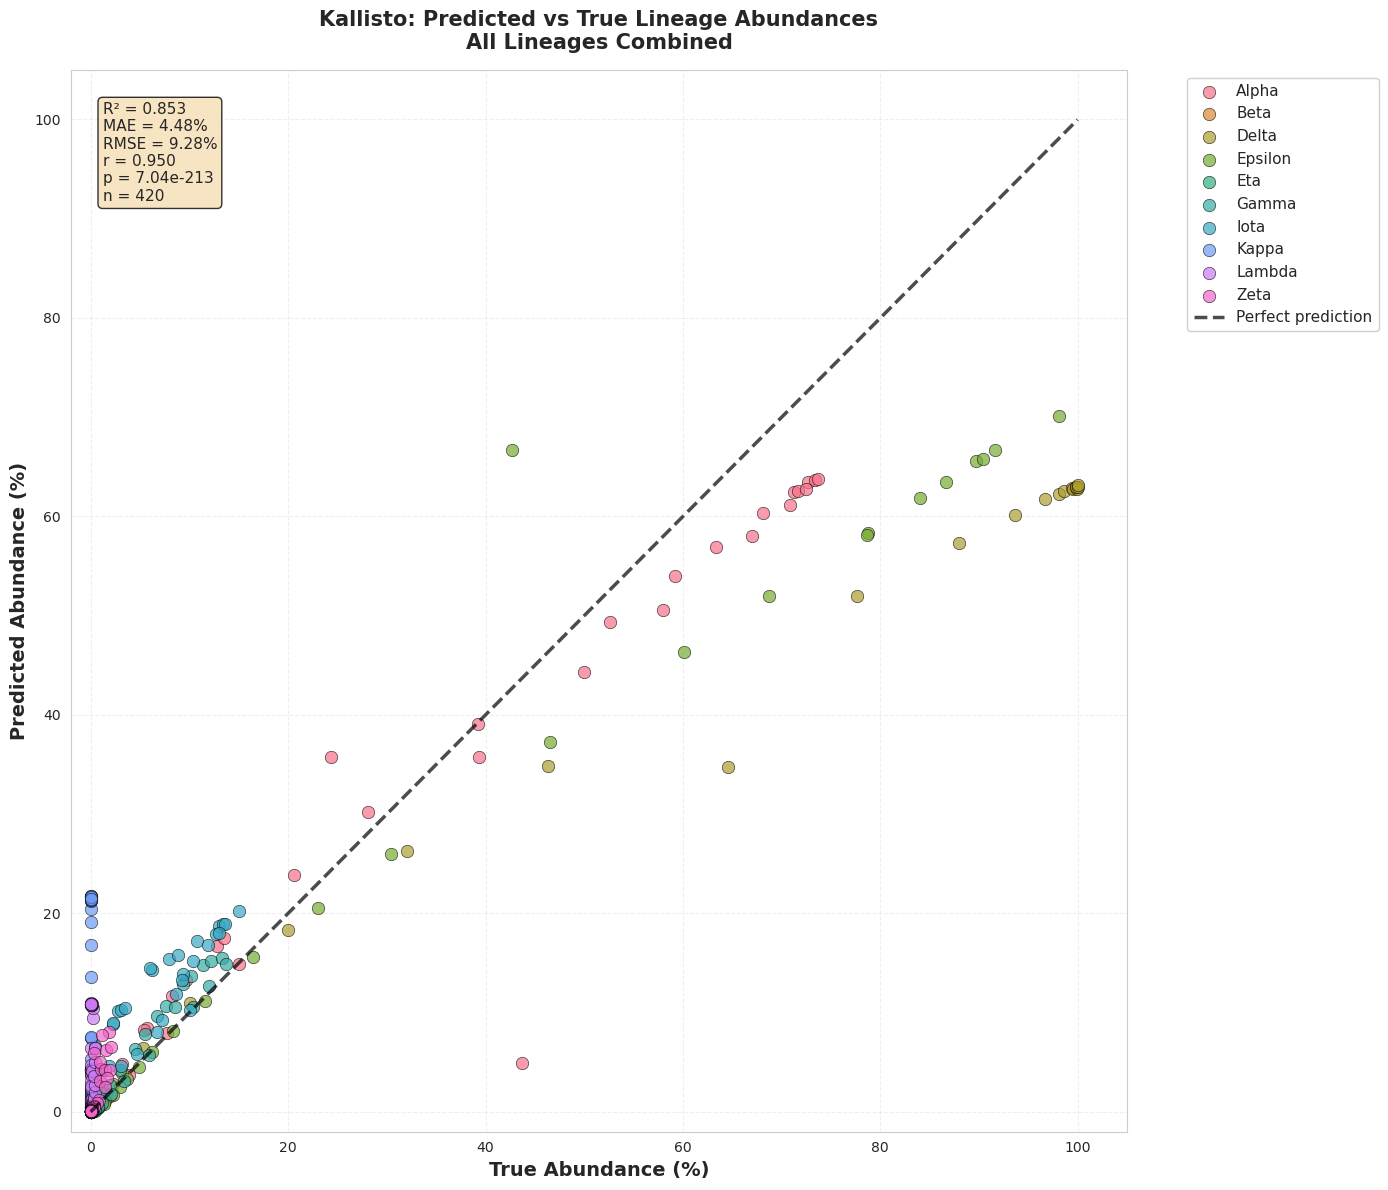

In [19]:
fig, ax = plt.subplots(figsize=(14, 12))

for lineage in kallisto_lineages:
    data = comparison_df_filtered[comparison_df_filtered['Lineage'] == lineage]
    if len(data) > 0:
        ax.scatter(data['True_Abundance'], data['Predicted_Abundance'], 
                  alpha=0.7, s=80, label=lineage, color=lineage_colors[lineage],
                  edgecolors='black', linewidth=0.5)

# Диагональная линия (идеальное предсказание)
max_val = max(comparison_df_filtered['True_Abundance'].max(), 
              comparison_df_filtered['Predicted_Abundance'].max())
ax.plot([0, max_val], [0, max_val], 'k--', lw=2.5, label='Perfect prediction', alpha=0.7)

ax.set_xlabel('True Abundance (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Predicted Abundance (%)', fontsize=14, fontweight='bold')
ax.set_title('Kallisto: Predicted vs True Lineage Abundances\nAll Lineages Combined', 
            fontsize=15, fontweight='bold', pad=15)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(-2, max_val + 5)
ax.set_ylim(-2, max_val + 5)

# Добавить метрики на график
textstr = (f'R² = {r2:.3f}\n'
          f'MAE = {mae:.2f}%\n'
          f'RMSE = {rmse:.2f}%\n'
          f'r = {pearson_r:.3f}\n'
          f'p = {pearson_p:.2e}\n'
          f'n = {len(comparison_df_filtered)}')
ax.text(0.03, 0.97, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', 
        facecolor='wheat', alpha=0.8, edgecolor='black'))

plt.tight_layout()
plt.savefig('kallisto_plots/kallisto_scatter_all_lineages.png', dpi=300, bbox_inches='tight')
plt.show()
# plt.close()

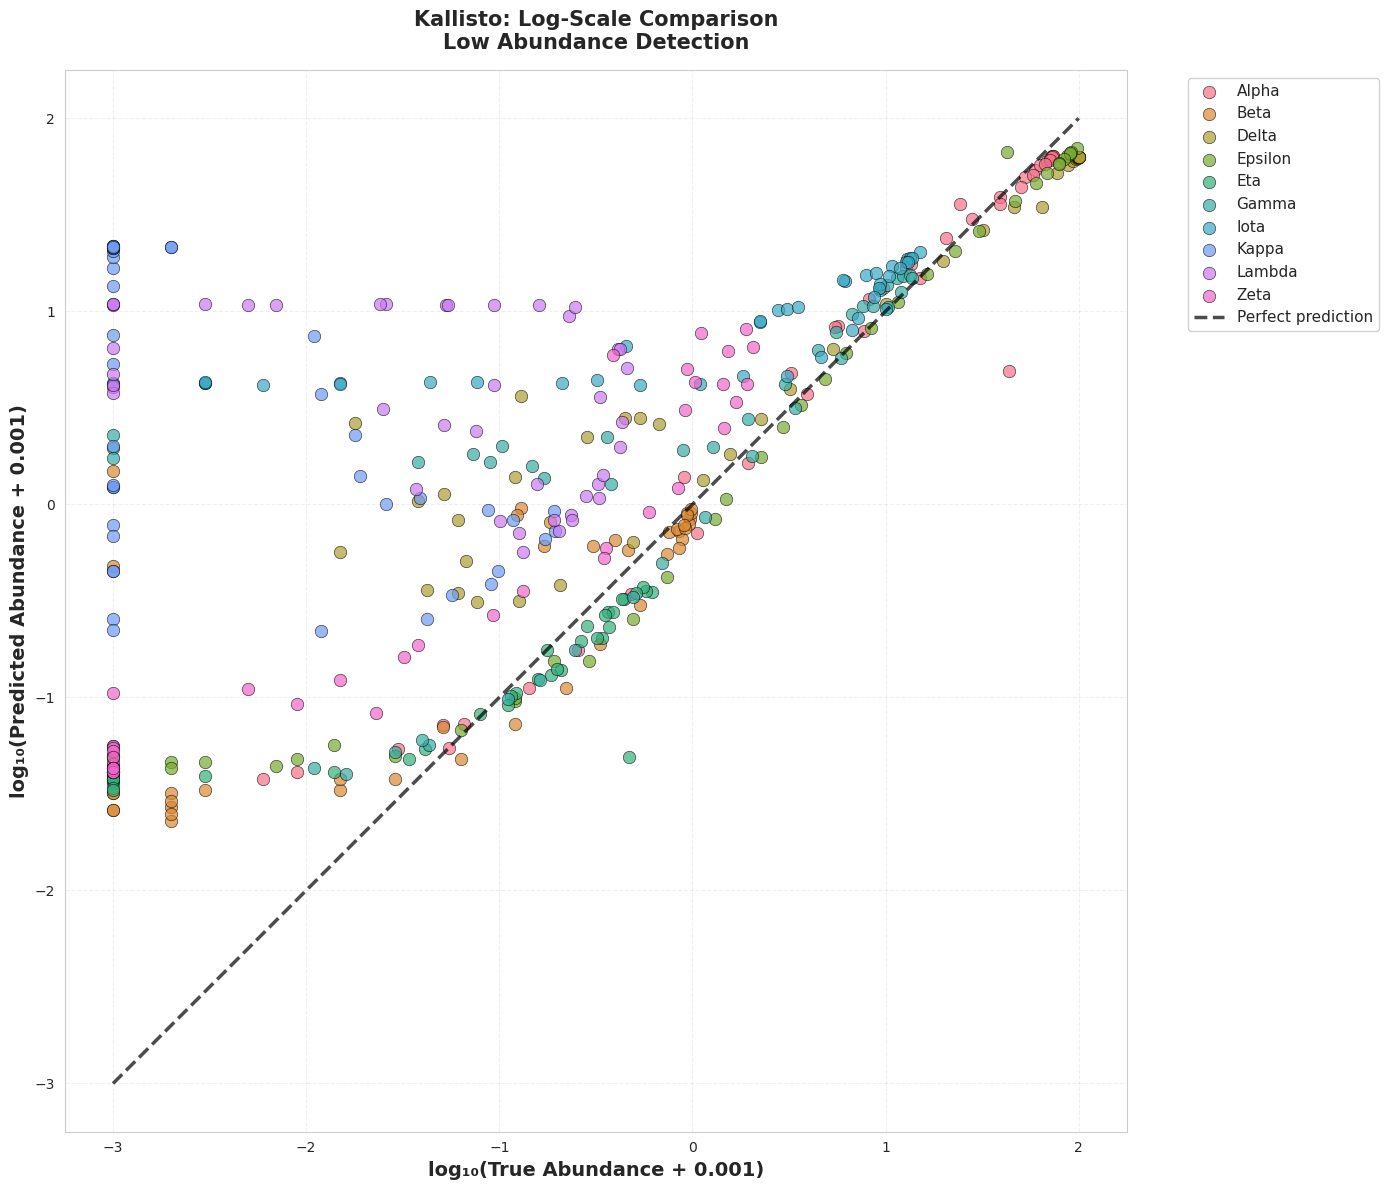

In [20]:
fig, ax = plt.subplots(figsize=(14, 12))

for lineage in kallisto_lineages:
    data = comparison_df_filtered[comparison_df_filtered['Lineage'] == lineage]
    if len(data) > 0:
        # Добавить малое значение чтобы избежать log(0)
        true_log = np.log10(data['True_Abundance'] + 0.001)
        pred_log = np.log10(data['Predicted_Abundance'] + 0.001)
        ax.scatter(true_log, pred_log, alpha=0.7, s=80, 
                  label=lineage, color=lineage_colors[lineage],
                  edgecolors='black', linewidth=0.5)

min_val = -3
max_val_log = 2
ax.plot([min_val, max_val_log], [min_val, max_val_log], 'k--', lw=2.5, 
        label='Perfect prediction', alpha=0.7)

ax.set_xlabel('log₁₀(True Abundance + 0.001)', fontsize=14, fontweight='bold')
ax.set_ylabel('log₁₀(Predicted Abundance + 0.001)', fontsize=14, fontweight='bold')
ax.set_title('Kallisto: Log-Scale Comparison\nLow Abundance Detection', 
            fontsize=15, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.savefig('kallisto_plots/kallisto_scatter_logscale.png', dpi=300, bbox_inches='tight')
plt.show()

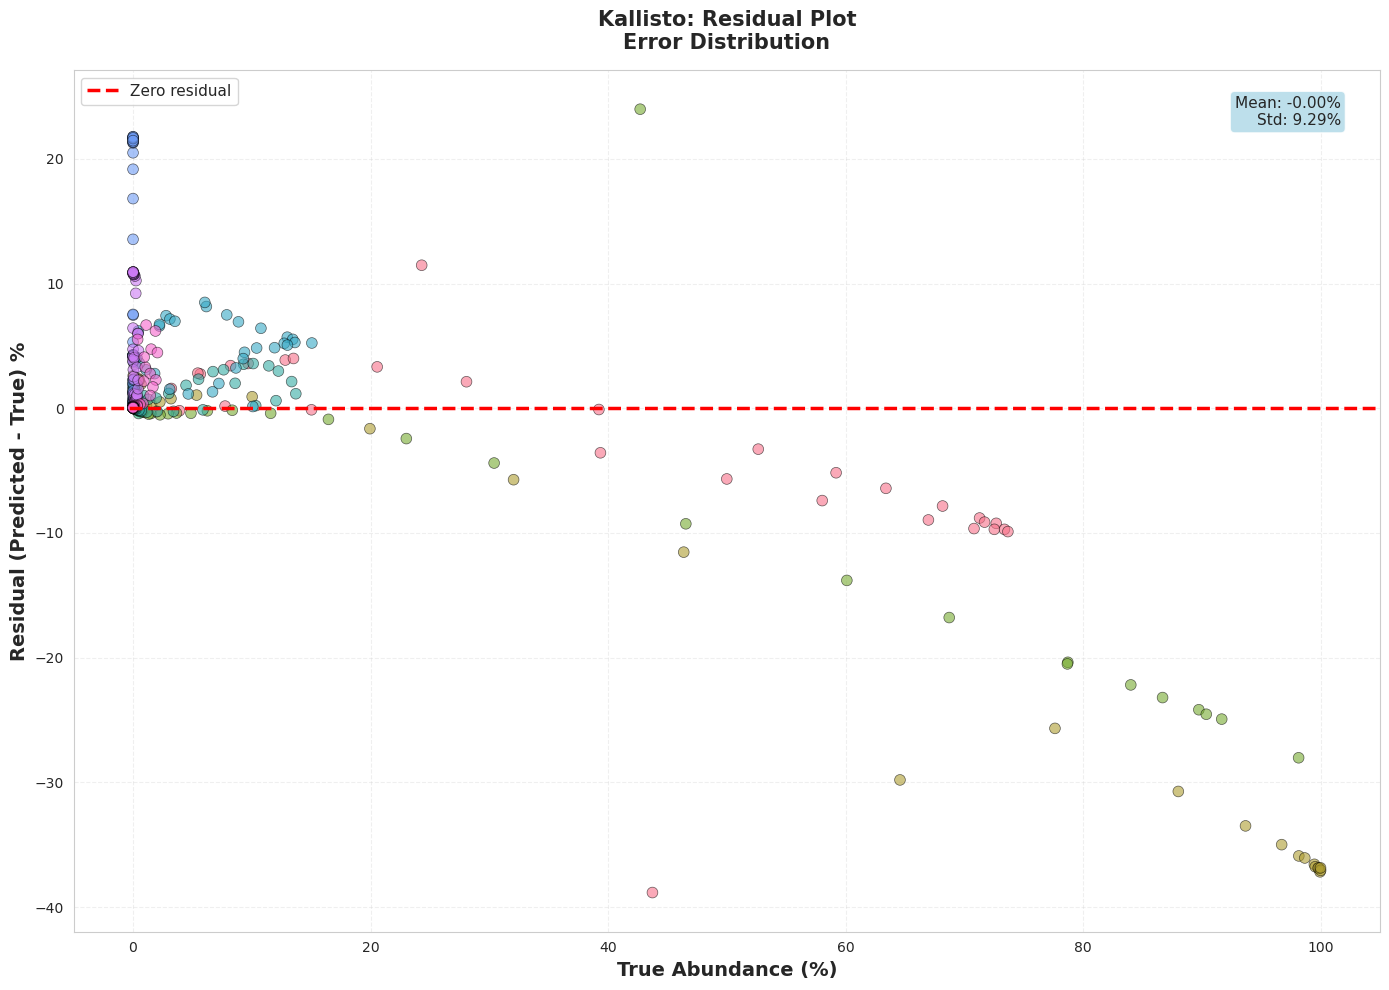

In [21]:
fig, ax = plt.subplots(figsize=(14, 10))

residuals = comparison_df_filtered['Predicted_Abundance'] - comparison_df_filtered['True_Abundance']
colors_residual = [lineage_colors[l] for l in comparison_df_filtered['Lineage']]
ax.scatter(comparison_df_filtered['True_Abundance'], residuals, 
          alpha=0.6, s=60, c=colors_residual, edgecolors='black', linewidth=0.5)
ax.axhline(y=0, color='red', linestyle='--', lw=2.5, label='Zero residual')
ax.set_xlabel('True Abundance (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Residual (Predicted - True) %', fontsize=14, fontweight='bold')
ax.set_title('Kallisto: Residual Plot\nError Distribution', fontsize=15, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11)

# Добавить статистику residuals
residual_mean = residuals.mean()
residual_std = residuals.std()
textstr = f'Mean: {residual_mean:.2f}%\nStd: {residual_std:.2f}%'
ax.text(0.97, 0.97, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.savefig('kallisto_plots/kallisto_residuals.png', dpi=300, bbox_inches='tight')
plt.show()

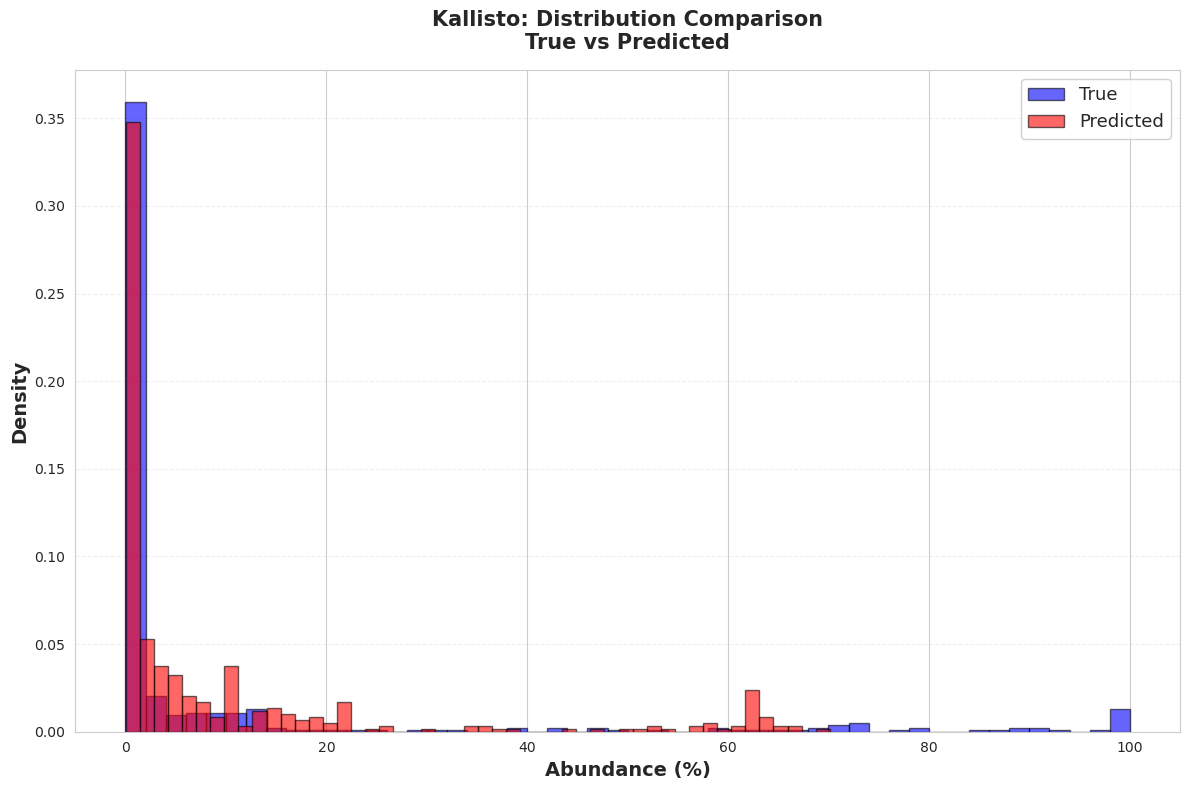

In [22]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.hist(comparison_df_filtered['True_Abundance'], bins=50, alpha=0.6, 
       label='True', color='blue', density=True, edgecolor='black')
ax.hist(comparison_df_filtered['Predicted_Abundance'], bins=50, alpha=0.6, 
       label='Predicted', color='red', density=True, edgecolor='black')
ax.set_xlabel('Abundance (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Density', fontsize=14, fontweight='bold')
ax.set_title('Kallisto: Distribution Comparison\nTrue vs Predicted', 
            fontsize=15, fontweight='bold', pad=15)
ax.legend(fontsize=13, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--', axis='y')

plt.tight_layout()
plt.savefig('kallisto_plots/kallisto_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

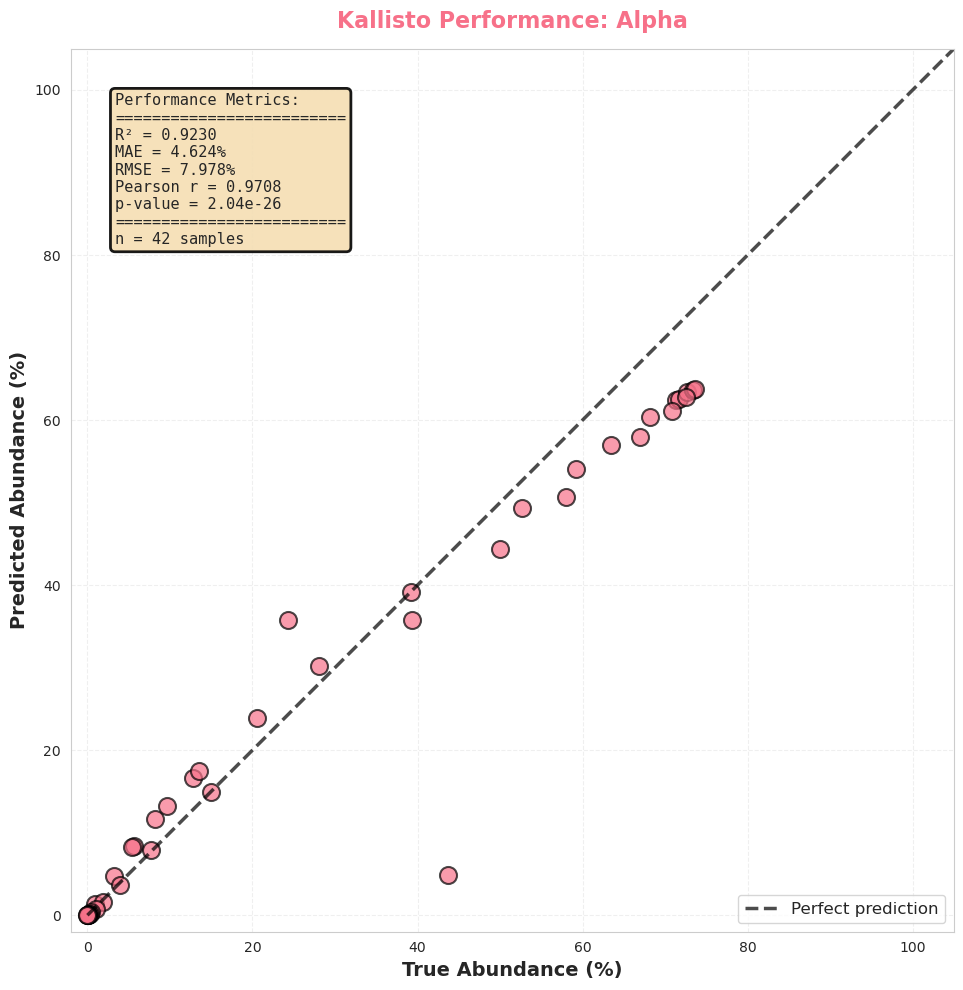

Сохранено: kallisto_plots/kallisto_scatter_Alpha.png


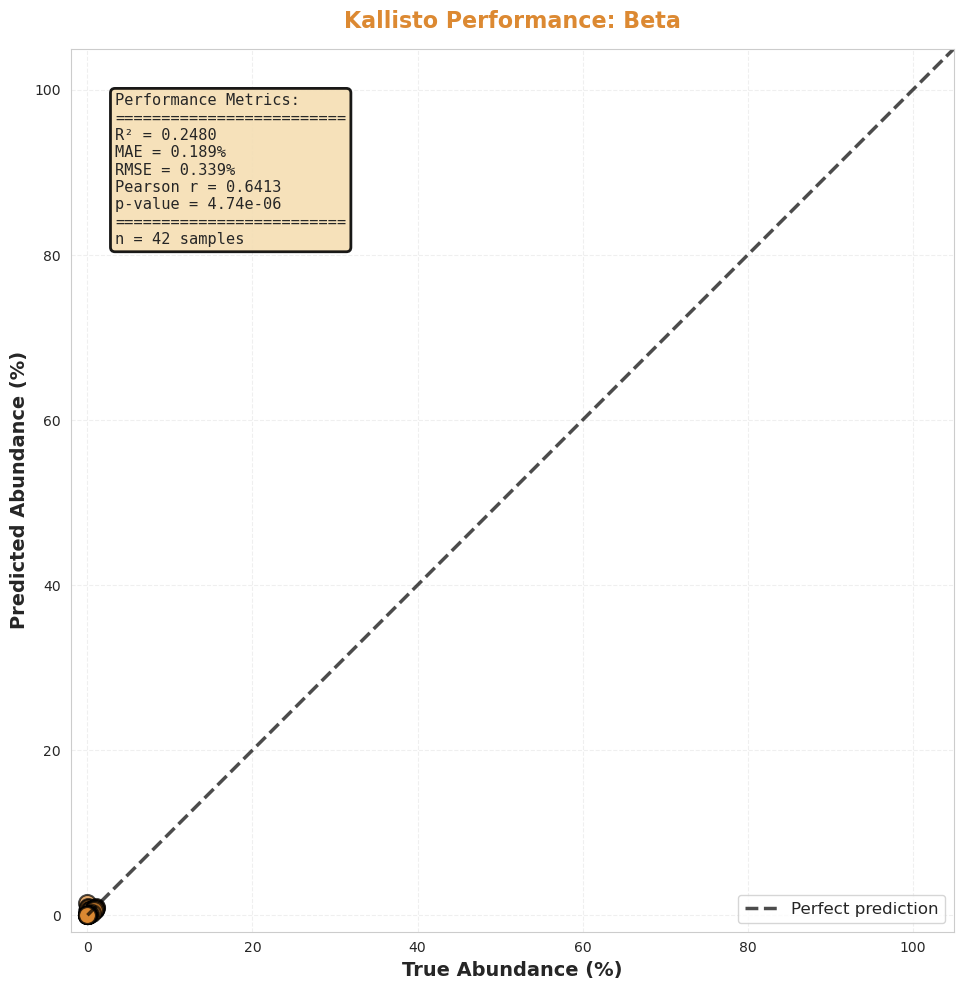

Сохранено: kallisto_plots/kallisto_scatter_Beta.png


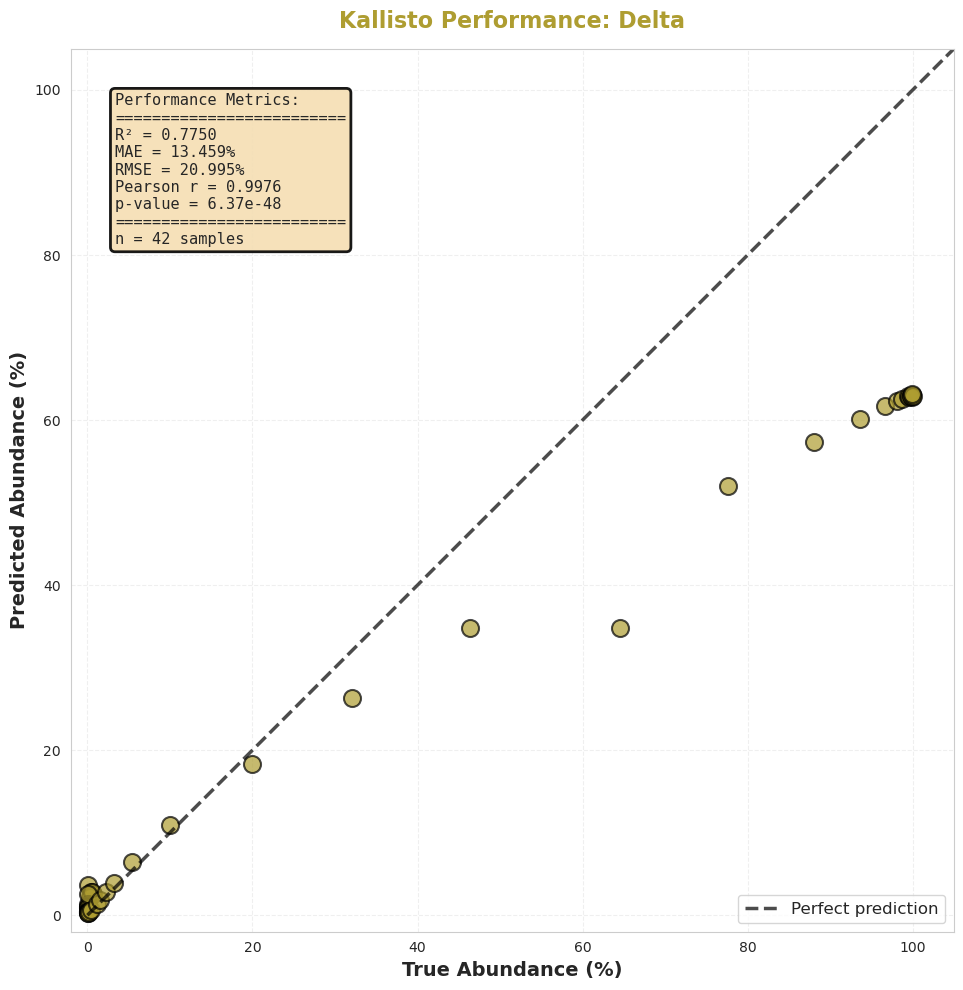

Сохранено: kallisto_plots/kallisto_scatter_Delta.png


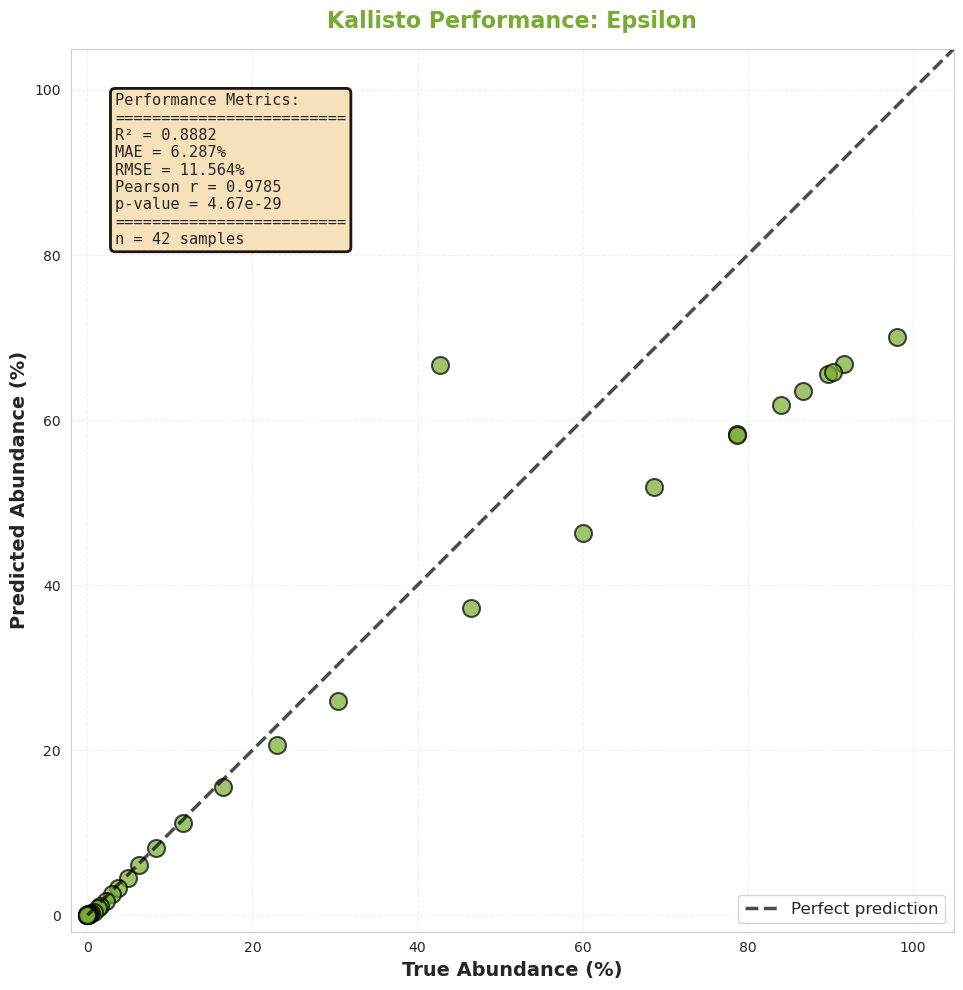

Сохранено: kallisto_plots/kallisto_scatter_Epsilon.png


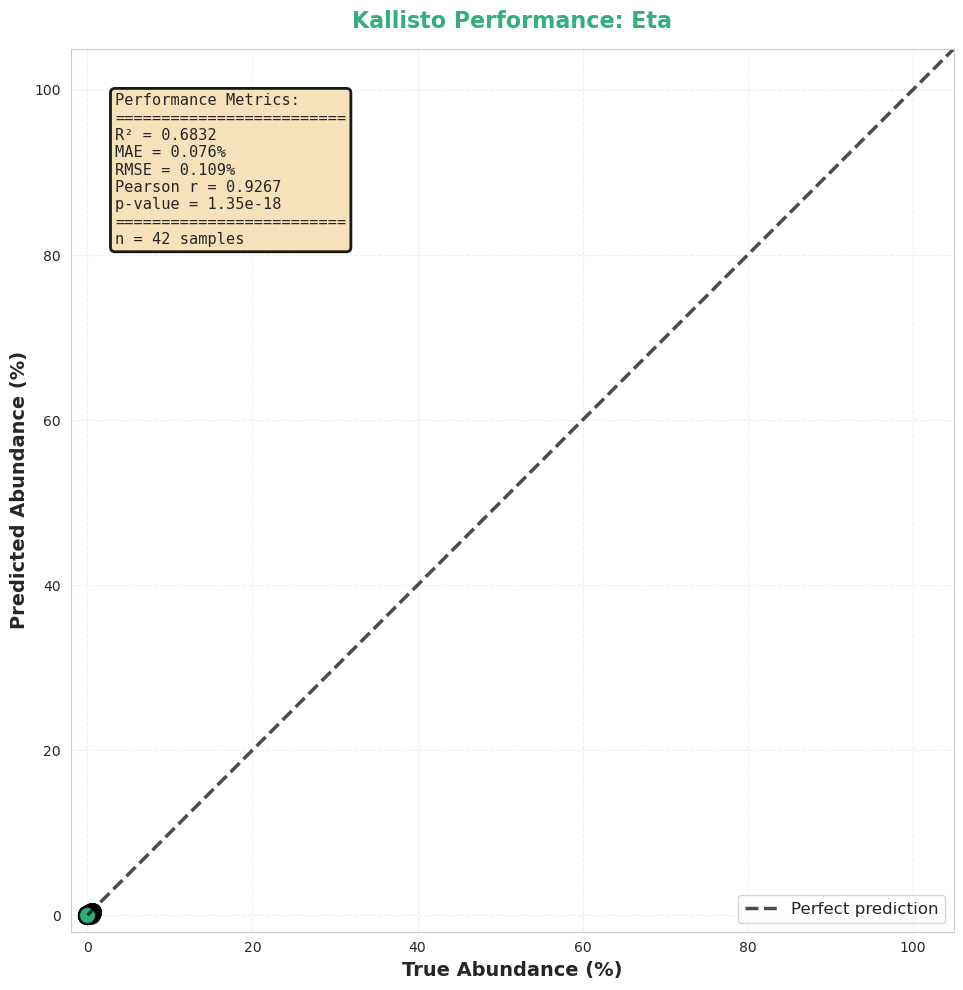

Сохранено: kallisto_plots/kallisto_scatter_Eta.png


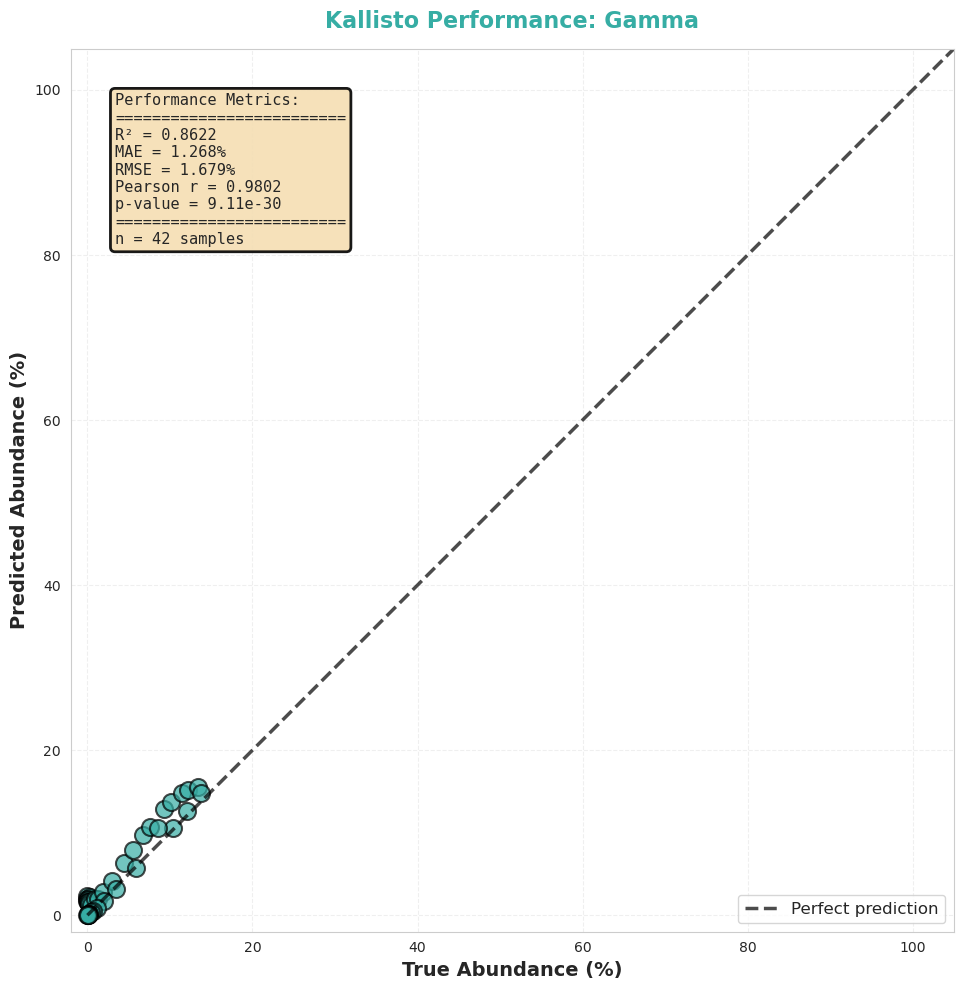

Сохранено: kallisto_plots/kallisto_scatter_Gamma.png


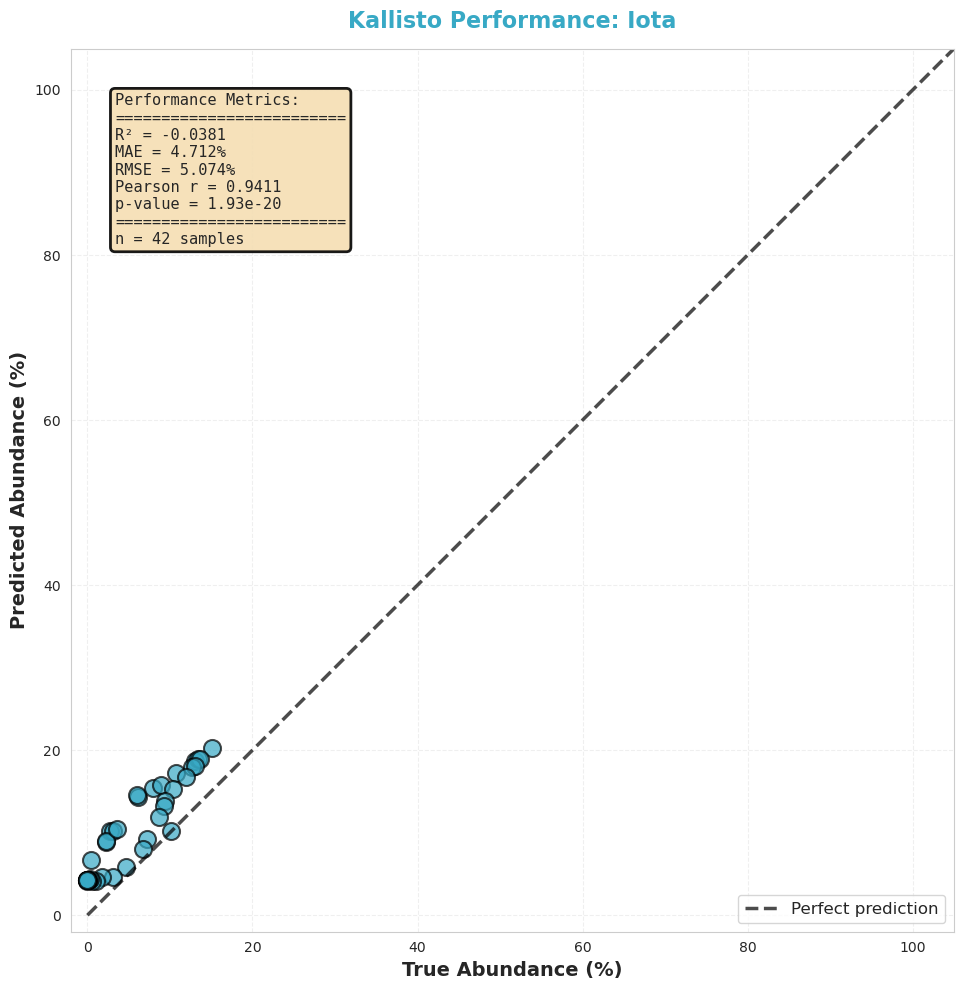

Сохранено: kallisto_plots/kallisto_scatter_Iota.png


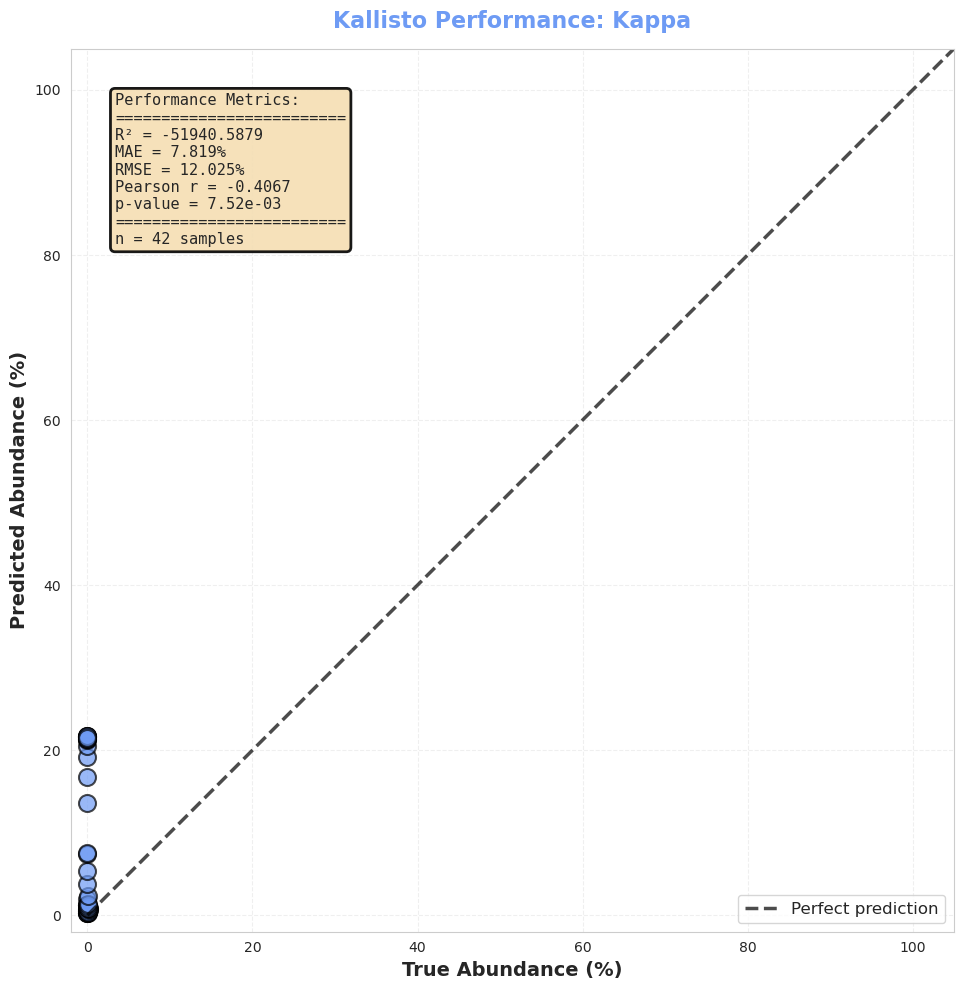

Сохранено: kallisto_plots/kallisto_scatter_Kappa.png


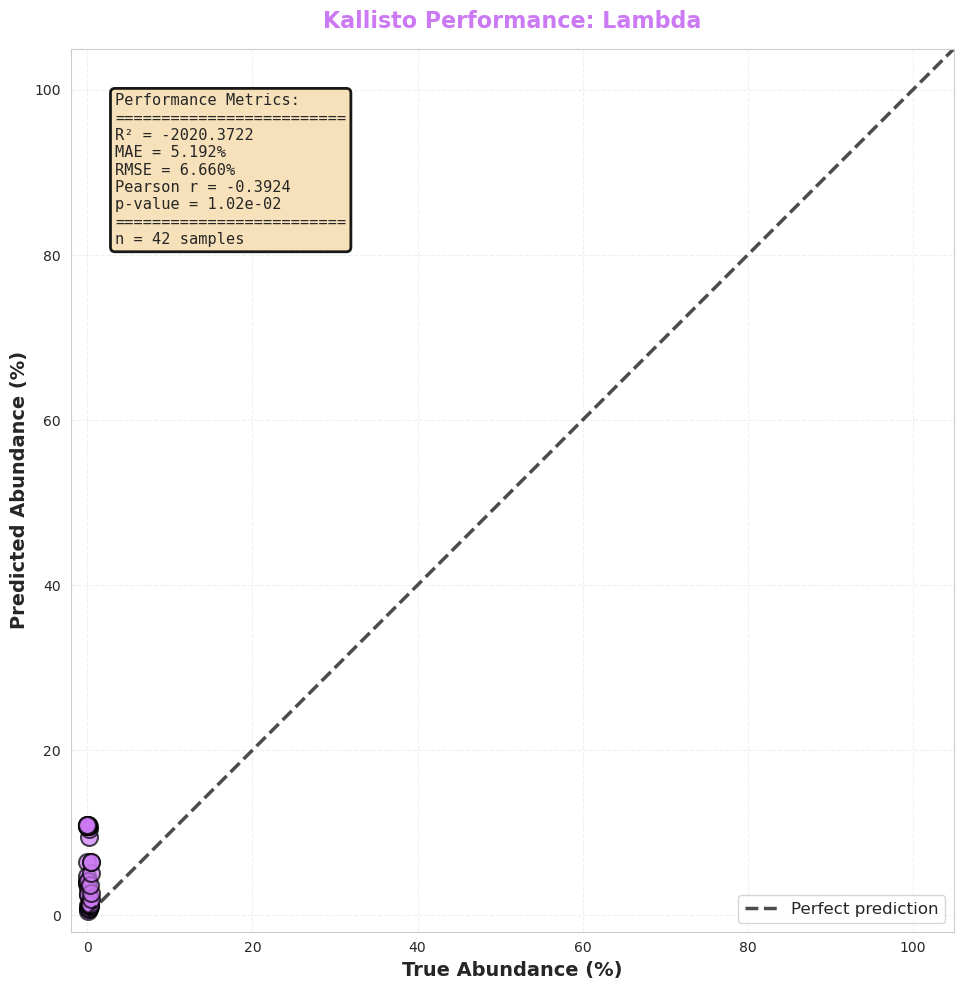

Сохранено: kallisto_plots/kallisto_scatter_Lambda.png


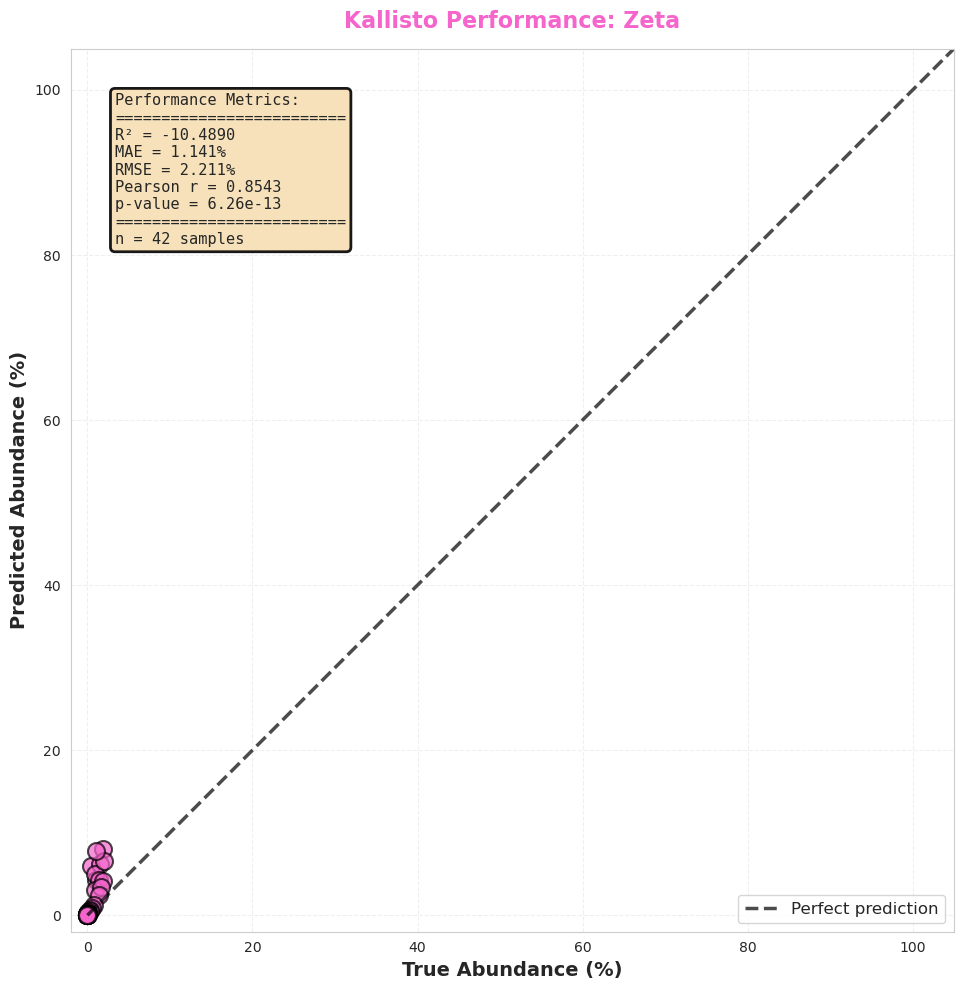

Сохранено: kallisto_plots/kallisto_scatter_Zeta.png


In [23]:
global_max = max(
    comparison_df_filtered['True_Abundance'].max(),
    comparison_df_filtered['Predicted_Abundance'].max()
)
axis_limit = global_max * 1.05

for lineage in kallisto_lineages:
    data = comparison_df_filtered[comparison_df_filtered['Lineage'] == lineage]
    
    if len(data) > 0:
        fig, ax = plt.subplots(figsize=(10, 10))
        
        ax.scatter(data['True_Abundance'], data['Predicted_Abundance'], 
                  alpha=0.7, s=150, color=lineage_colors[lineage],
                  edgecolors='black', linewidth=1.5)
        
        # Линия идеального предсказания
        ax.plot([0, axis_limit], [0, axis_limit], 'k--', lw=2.5, alpha=0.7,
               label='Perfect prediction')
        
        # Метрики для этой линии
        if len(data) > 2:
            lineage_r2 = r2_score(data['True_Abundance'], data['Predicted_Abundance'])
            lineage_mae = mean_absolute_error(data['True_Abundance'], data['Predicted_Abundance'])
            lineage_rmse = np.sqrt(mean_squared_error(data['True_Abundance'], data['Predicted_Abundance']))
            lineage_pearson, lineage_p = stats.pearsonr(data['True_Abundance'], data['Predicted_Abundance'])
            
            textstr = (f'Performance Metrics:\n'
                      f'{"="*25}\n'
                      f'R² = {lineage_r2:.4f}\n'
                      f'MAE = {lineage_mae:.3f}%\n'
                      f'RMSE = {lineage_rmse:.3f}%\n'
                      f'Pearson r = {lineage_pearson:.4f}\n'
                      f'p-value = {lineage_p:.2e}\n'
                      f'{"="*25}\n'
                      f'n = {len(data)} samples')
            ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=11,
                   verticalalignment='top', bbox=dict(boxstyle='round', 
                   facecolor='wheat', alpha=0.9, edgecolor='black', linewidth=2),
                   family='monospace')
        
        ax.set_xlabel('True Abundance (%)', fontsize=14, fontweight='bold')
        ax.set_ylabel('Predicted Abundance (%)', fontsize=14, fontweight='bold')
        ax.set_title(f'Kallisto Performance: {lineage}', 
                    fontsize=16, fontweight='bold', pad=15,
                    color=lineage_colors[lineage])
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.legend(fontsize=12, loc='lower right')
        
        # Одинаковый масштаб для всех
        ax.set_xlim(-2, axis_limit)
        ax.set_ylim(-2, axis_limit)
        ax.set_aspect('equal', adjustable='box')
        
        plt.tight_layout()
        plt.savefig(f'kallisto_plots/kallisto_scatter_{lineage}.png', dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Сохранено: kallisto_plots/kallisto_scatter_{lineage}.png")

✅ Сохранено: kallisto_plots/kallisto_error_heatmap.png
✅ Сохранено: kallisto_plots/kallisto_scatter_with_stats.png


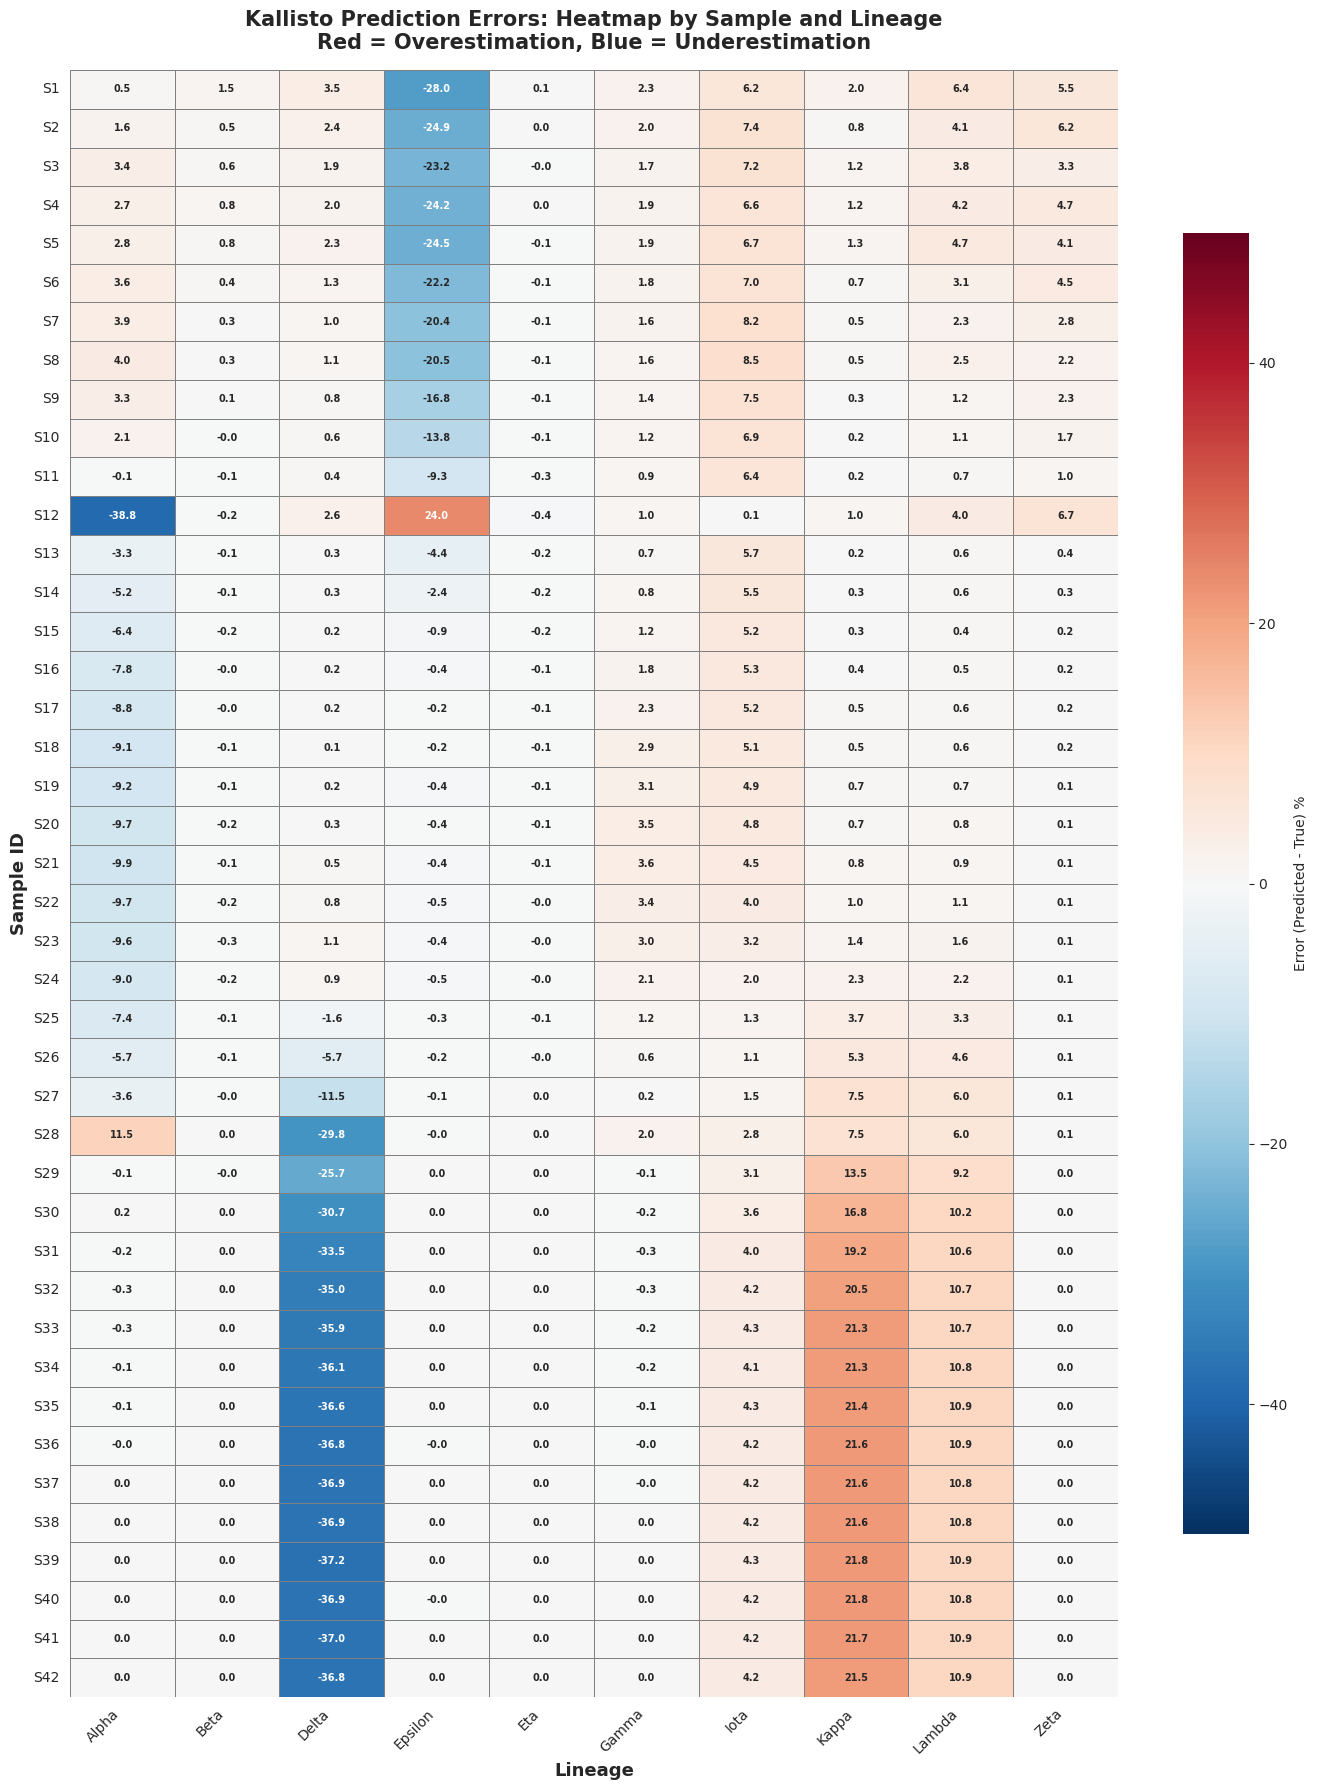

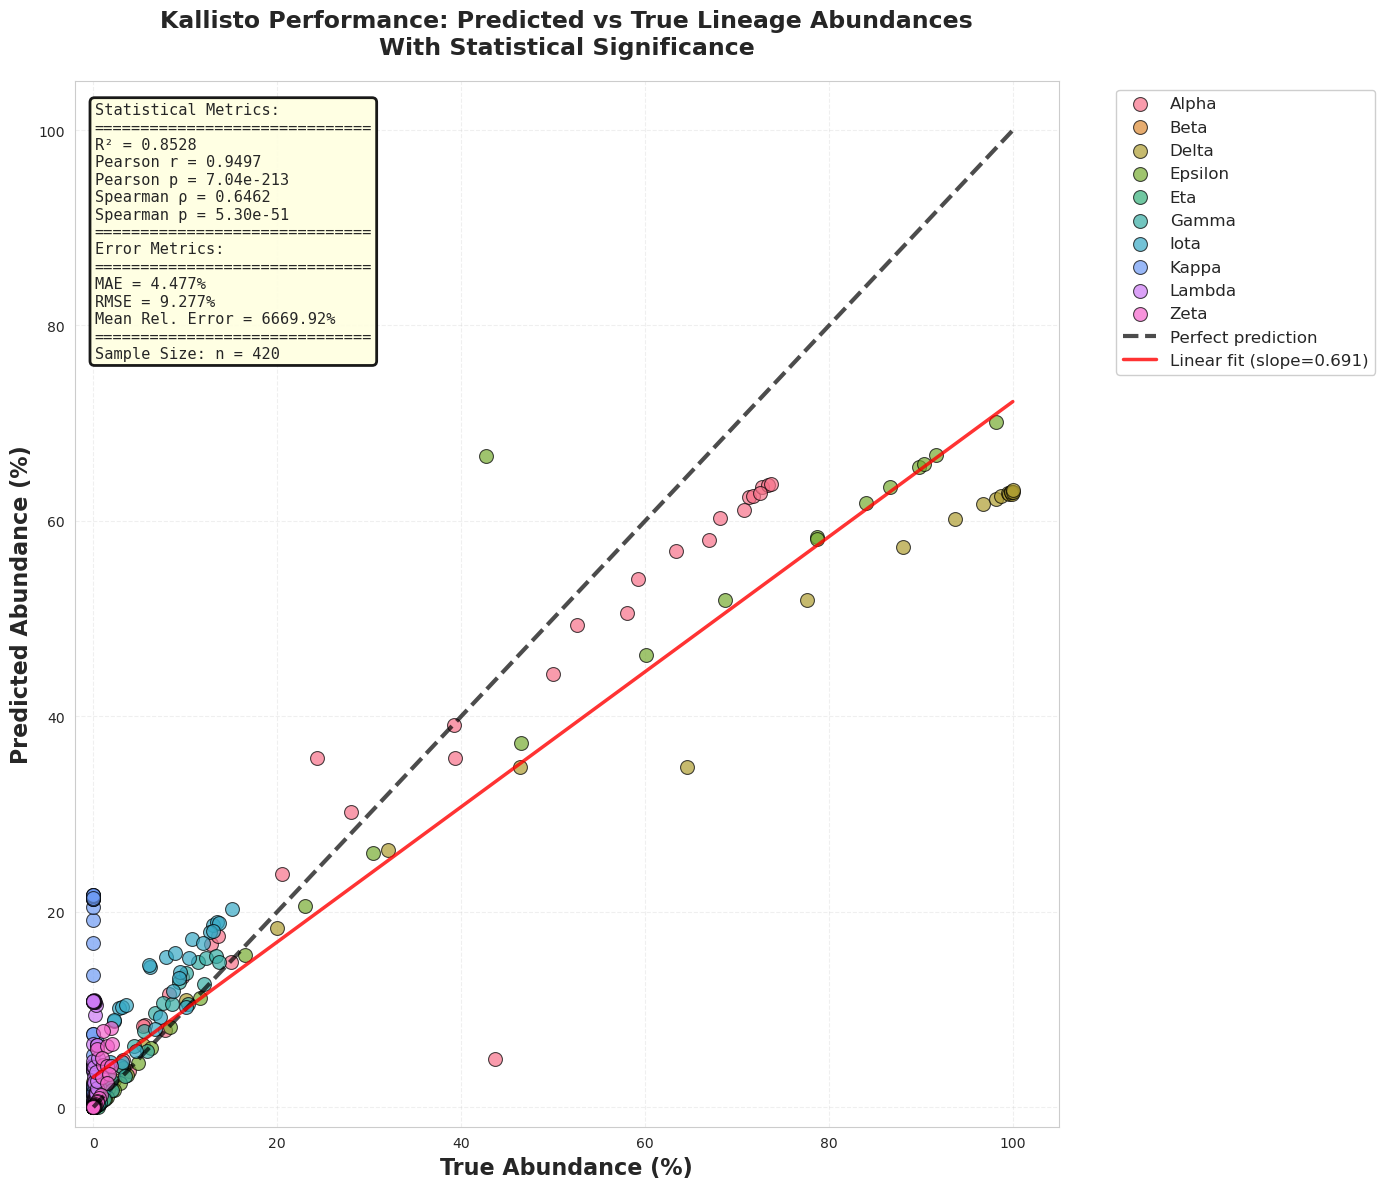

In [24]:
# Figure 3: Heatmap ошибок
pivot_pred = comparison_df.pivot_table(
    values='Predicted_Abundance', 
    index='Sample', 
    columns='Lineage', 
    aggfunc='first'
).fillna(0)

pivot_true = comparison_df.pivot_table(
    values='True_Abundance', 
    index='Sample', 
    columns='Lineage', 
    aggfunc='first'
).fillna(0)

error_matrix = pivot_pred - pivot_true

# Сортировка сэмплов численно
def sort_samples(sample_names):
    """Сортировка сэмплов численно (S1, S2, ..., S42)"""
    import re
    def extract_number(s):
        match = re.search(r'(\d+)', str(s))
        return int(match.group(1)) if match else 0
    return sorted(sample_names, key=extract_number)

sorted_samples = sort_samples(error_matrix.index.tolist())
sorted_lineages = sorted(error_matrix.columns.tolist())

error_matrix = error_matrix.loc[sorted_samples, sorted_lineages]

plt.figure(figsize=(14, 18))
sns.heatmap(error_matrix, 
           cmap='RdBu_r', 
           center=0, 
           cbar_kws={'label': 'Error (Predicted - True) %', 'shrink': 0.8},
           vmin=-50, 
           vmax=50, 
           linewidths=0.5, 
           linecolor='gray',
           annot=True,
           fmt='.1f',
           annot_kws={'size': 7, 'weight': 'bold'})  # BOLD!

plt.title('Kallisto Prediction Errors: Heatmap by Sample and Lineage\n' + 
         'Red = Overestimation, Blue = Underestimation', 
         fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Lineage', fontsize=13, fontweight='bold')
plt.ylabel('Sample ID', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('kallisto_plots/kallisto_error_heatmap.png', dpi=300, bbox_inches='tight')
print("✅ Сохранено: kallisto_plots/kallisto_error_heatmap.png")


# Figure 4: Scatter plot с аннотациями r и p-value
fig, ax = plt.subplots(figsize=(14, 12))

for lineage in kallisto_lineages:
    data = comparison_df_filtered[comparison_df_filtered['Lineage'] == lineage]
    if len(data) > 0:
        ax.scatter(data['True_Abundance'], data['Predicted_Abundance'], 
                  alpha=0.7, s=100, label=lineage, color=lineage_colors[lineage],
                  edgecolors='black', linewidth=0.8)

max_val = max(comparison_df_filtered['True_Abundance'].max(), 
              comparison_df_filtered['Predicted_Abundance'].max())
ax.plot([0, max_val], [0, max_val], 'k--', lw=3, label='Perfect prediction', alpha=0.7)

slope, intercept, r_value, p_value, std_err = stats.linregress(
    comparison_df_filtered['True_Abundance'], 
    comparison_df_filtered['Predicted_Abundance']
)
x_line = np.array([0, max_val])
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, 'r-', lw=2.5, alpha=0.8, label=f'Linear fit (slope={slope:.3f})')

ax.set_xlabel('True Abundance (%)', fontsize=16, fontweight='bold')
ax.set_ylabel('Predicted Abundance (%)', fontsize=16, fontweight='bold')
ax.set_title('Kallisto Performance: Predicted vs True Lineage Abundances\nWith Statistical Significance', 
            fontsize=17, fontweight='bold', pad=20)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(-2, max_val + 5)
ax.set_ylim(-2, max_val + 5)

textstr = (f'Statistical Metrics:\n'
          f'{"="*30}\n'
          f'R² = {r2:.4f}\n'
          f'Pearson r = {pearson_r:.4f}\n'
          f'Pearson p = {pearson_p:.2e}\n'
          f'Spearman ρ = {spearman_r:.4f}\n'
          f'Spearman p = {spearman_p:.2e}\n'
          f'{"="*30}\n'
          f'Error Metrics:\n'
          f'{"="*30}\n'
          f'MAE = {mae:.3f}%\n'
          f'RMSE = {rmse:.3f}%\n'
          f'Mean Rel. Error = {mean_relative_error:.2f}%\n'
          f'{"="*30}\n'
          f'Sample Size: n = {len(comparison_df_filtered)}')

ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', 
        facecolor='lightyellow', alpha=0.9, edgecolor='black', linewidth=2),
        family='monospace')

plt.tight_layout()
plt.savefig('kallisto_plots/kallisto_scatter_with_stats.png', dpi=300, bbox_inches='tight')
print("✅ Сохранено: kallisto_plots/kallisto_scatter_with_stats.png")

# Продолжить с сохранением результатов как было...